# LSTM(장기 의존성 학습 모델)
- RNN 구조에서 발생하는 문제를 해결하기 위해 구조를 변경한 모델
- 기존의 RNN은 학습의 횟수가 증가 -> 과거의 기억을 잃는다.
    - 반복 학습을 하면서 가중치의 변화량이 0에 가까워짐을 의미
    - 손실 함수 -> tanh -> 반복적으로 tanh() 함수를 실행하게 되면 변화량 0
    - LSTM은 반복 학습을 하면서 과거의 기억 중 장기 기억과, 단기 기억으로 나눠주는 역할
        - 반복 학습을 하면서 tanh() 중복적으로 실행이 되면 기울기 변화량이 줄어듬
        - 장기 기억은 tanh()함수를 실행하지 않고 -> 가중치의 변화를 계속한다.
        - 셀이라는 공간에 장기 기억 정보를 전달
        - 게이트로 정도를 선택적으로 보관. 삭제, 출력

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


In [3]:
# 데이터로드
df = pd.read_csv("../csv/AAPL.csv")

In [4]:
# Date 컬럼의 dtype을 시계열 데이터로 변환
# 문자형 데이터를 시계열 데이터로 변환 -> 그래프 시각화할때 X축의 데이터로 사용하기 위함

df['Date'] = pd.to_datetime(
    df['Date']
)

In [5]:
# 특정 컬럼 선택
df = df[['Date', 'Adj Close', 'Volume']]
# 결측치가 포함되어있는 행을 모두 제거
df.dropna(axis=0, inplace=True)

In [6]:
# 독립 데이터, 종속 데이터를 생성
X_all = df[['Adj Close', 'Volume']]
Y_all = df[['Adj Close']]

In [7]:
# 데이터 8:2 비율로 나눠준다.
split_idx = int(len(df) * 0.8)
X_train, X_test = X_all[: split_idx], X_all[split_idx:]
Y_train, Y_test = Y_all[: split_idx], Y_all[split_idx :]

print(X_train.shape, Y_test.shape)
print(Y_train.shape, Y_test.shape)

(7770, 2) (1943, 1)
(7770, 1) (1943, 1)


In [8]:
# 초기 설정 값
# 시계열 데이터의 구간(과거 데이터의 개수)
window = 60

# 학습 루프에서 루프의 수
epochs = 20

# 학습 데이터의 배치의 개수
x_batch = 64

# optimizer lr 값 (학습율)
lr = 0.001

# 은닉 층의 뉴런의 개수
hidden_cnt = 64

# 랜덤의 일반화
torch.manual_seed(42)

# 은닉층, 셀 사용여부
head_type = 'h'

In [9]:
class WindowDataset(Dataset):
    # 입력 데이터와 타깃 데이터를 받아서
    # 구간의 수만큼 입력데이터를 잘라주고
    # 해당 구간 바로 다음행의 타킷 데이터를 되돌려준다.
    # DataLoader 클래스에서 사용하기 위함
    def __init__(
        self, _x, _y, _window
    ):
        self.x = _x
        self.y = _y
        self.window = _window
        # n의 값은 구간의 데이터 시작 지점의 최대값
        self.n = len(_x) - _window
        
    def __len__(self):
        # window의 수치가 x의 길이보다 큰 경우에는 1을 되돌려준다.
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        # idx : 구간의 시점 지점 -> 최대 값은 self.n
        x_window = self.x[idx : idx + self.window]
        # idx + window 위치의 데이터 -> 단일값 생성
        y_next = self.y[idx + self.window]
        # tensor형의 변환
        x_tensor = torch.from_numpy(x_window).float()
        y_tensor = torch.from_numpy(y_next)
        
        return x_tensor, y_tensor

In [10]:
# 데이터를 스케일링 -> MinMaxSclaer
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(Y_train)

X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)

Y_train = y_scaler.transform(Y_train)
Y_test = y_scaler.transform(Y_test)



In [11]:
# WindowDataset 생성
# 객체를 생성하고 getitem() 함수를 사용한다면 window(60) 구간의 데이터와 해당 구간 다음 행의 종가 데이터를 되돌려주는 class
train_ds = WindowDataset(X_train, Y_train, window)
test_ds = WindowDataset(X_test, Y_test, window)


In [12]:
# DataLoader -> WindowDataset class를 이용하여 ds_data에서 len() 함수를 이용하여 해당 구간에서 가장 마지막에 사용 가능한 시작
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=x_batch)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=x_batch)


In [13]:
# for x, y in train_dl:
#     print("구간 데이터 :", x)
#     print("다음 날의 종가 :", y)
#     break

In [ ]:
# LSTM 모델 정의

class LSTMReg(nn.Module):
    # h : 마지막의 은닉층은 데이터를 이용(RNN -> 기억 소실, LSTM -> 장기 기억)
    # c : 셀의 데이터를 이용
    # h_c : 은닉층 + 셀의 데이터를 이용
    def __init__(
        self,
        input_size, hidden_size,
        num_layers=1, dropout=0.0,
        bidireactional = False,
        head_type= head_type,
        
    ):
        super().__init__()
        
        # lstm 기본 설정
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            dropout= dropout,
            bidirectional= bidireactional,
            # batch_first 매개변수
                # 기본값은 False
                # RNN, LSTM의 기본적인 입력값의 형태는 (구간의 수, 배치의 수, 피져의 수)
                # True로 변경시 (배치의 개수, 구간의 수, 피쳐의 수)의 형태로 입력값을 확인
                # Dataloader에서 봔환하는 데이터의 형태는 (배치의 개수, 구간의 수, 피져의 수)이기 때문에 해당 매개변수를 True로 변경
            batch_first= True
        )
        
        # bidirectional이 True인 경우 차원의 개수 * 2
        out_dim = hidden_size * (2 if bidireactional else 1)
        # head_type은 은닉층만 사용하거나 셀만 사용하거나 -> 차원의 개수 * 1
        if head_type in ['h', 'c']:
            head_in = out_dim
        elif head_type == 'h_c':
            head_in = out_dim * 2
        else:
            print('head_type Error')
            
        self.head = nn.Sequential(
            nn.Linear(head_in, 1)
        )
        self.head_type = head_type
        
    # 순전파 함수
    def forward(self, x):
        # 순전파의 예측 결과 값
        out, (h_n, c_n) = self.lstm(x)
        # 은닉층 중 마지막 은닉층을 저장
        h_last = h_n[-1]
        # 셀 마지막 셀
        c_last = torch.tanh(c_n[-1])
        
        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last, c_last], dim = -1)
            
        return self.head(feat)
        

In [ ]:
# 순전파 -> 손실 -> 역전파 -> 옵티마이저

# 모델을 생성
model = LSTMReg(input_size=2, hidden_size=hidden_cnt,
                head_type=head_type)
model

LSTMReg(
  (lstm): LSTM(2, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [18]:
# 손실 함수 -> 회귀 모델(MSELoss) : 정답이 존재하지만 정확한 정답을 맞추기는 쉽지 않다.
#             분류 모델(CrossEntropyLoss) : 정답을 정확하게 맞췄는가? -> 이진 분류, 다중 분류

criterion = nn.MSELoss()
# 가중치의 변화 (학습에 대한 가중의 변화)
# SGD(단순 경사 하강) -> 스텝 별 가중치의 변화량이 일정
# Adam -> 학습율에 따른 동작인 가중치 변화
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [24]:
# Loss를 구하는 함수를 생성 -> torch의 모델은 자동 미분이 활성화를 비활성화로 바꾸고 작업
# Loss의 값을 구하는 경우 루프가 끝나고 지정하기 때문에 미분 계산이 무의미 (비활성화)
# 계산이 비활성화가 되기 때문에 메모리 효율 증가, 속도 빨라진다.
@torch.no_grad()
def evaluate_mse(dl):
    # eval() : 해당 모델의 평가 모드로 변환
    model.eval()
    # 총 로스, 총 개수 초기 값 지정
    total_loss = 0.0
    total_n = 0
    # DataLoader를 매개변수로 입력을 받아서 사용 -> batch_size의 개수가 존재
    for x, y in dl:
        # x-> 독립변수 (문제)
        # y -> 종속변수 (답)
        # torch에서 계산은 float 형태에서 계산
        x = x.float()
        y = y.float()
        # 예측
        pred = model(x)
        # 예측 값과 실제 값의 loss 확인
        loss = criterion(pred, y)   # 평균 손실 데이터
        # 총 손실 * y의 크기 -> 총 손실을 누적합
        total_loss += loss.item() * y.size(0)
        # 총 개수도 누적합
        total_n += y.size(0)
    # 함수에서 되돌려주는 결과 값 -> total_loss / total_n
    # torch_Size가 0인 경우라면 -> 0 / 0 --> Error 발생 -> 분모는 max() 이용
    return total_loss / max(total_n, 1)


In [26]:
# 학습 루프 (반복 학습) : (순전파 -> 손실 -> 역전파 -> 옵티마이저) -> 하나의 스텝
# loss의 값의 변화를 저장
train_history = []
test_history = []

# train인 DataLoader를 이용하여 반복문을 실행
for epoch in range(epochs):
    # 모델의 학습 모드로 변환
    model.train()
    # 총 손실에 대한 평균을 구하기 위해 총 로스, 총 개수의 초기값을 설정
    tot_loss=0.0
    tot_n = 0
    # train인 DataLoader를 이용하여 반복문을 실행
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        
        # 학습 루프가 반복적으로 실행이 되기 때문에 미분의 값을 초기화
        optimizer.zero_grad()
        # 모델의 학습 데이터를 학습하여 예측
        pred = model(x)
        # 예측값과 실제 값의 차이를 계산
        loss = criterion(pred, y)
        # 역전
        loss.backward()
        # 기울기가 너무 급격하게 변화해서 폭주하는 상황은 방지
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        # 총 손실의 누적합
        tot_loss += loss.item() * y.size(0)
        # 총 개수의 누적합
        tot_n += y.size(0)
        
    # train 데이터에 총 loss의 평균
    train_loss = tot_loss / max(tot_n, 1)
    # test 데이터에 총 loss의 평균
    test_loss = evaluate_mse(test_dl)
    # loss 내역을 저장
    train_history.append(train_loss)
    test_history.append(test_loss)
    print(f"epoch : {epoch + 1}, train_mse : {round(train_loss, 4)},        test_mse : {round(test_loss, 4)}")

epoch : 1, train_mse : 0.0,        test_mse : 0.0489
epoch : 2, train_mse : 0.0,        test_mse : 0.0534
epoch : 3, train_mse : 0.0,        test_mse : 0.0496
epoch : 4, train_mse : 0.0,        test_mse : 0.0521
epoch : 5, train_mse : 0.0,        test_mse : 0.0452
epoch : 6, train_mse : 0.0,        test_mse : 0.0485
epoch : 7, train_mse : 0.0,        test_mse : 0.04
epoch : 8, train_mse : 0.0,        test_mse : 0.0333
epoch : 9, train_mse : 0.0,        test_mse : 0.0408
epoch : 10, train_mse : 0.0,        test_mse : 0.0475
epoch : 11, train_mse : 0.0,        test_mse : 0.0379
epoch : 12, train_mse : 0.0,        test_mse : 0.042
epoch : 13, train_mse : 0.0,        test_mse : 0.0487
epoch : 14, train_mse : 0.0,        test_mse : 0.0374
epoch : 15, train_mse : 0.0,        test_mse : 0.0363
epoch : 16, train_mse : 0.0,        test_mse : 0.0389
epoch : 17, train_mse : 0.0,        test_mse : 0.0397
epoch : 18, train_mse : 0.0,        test_mse : 0.0407
epoch : 19, train_mse : 0.0,        test

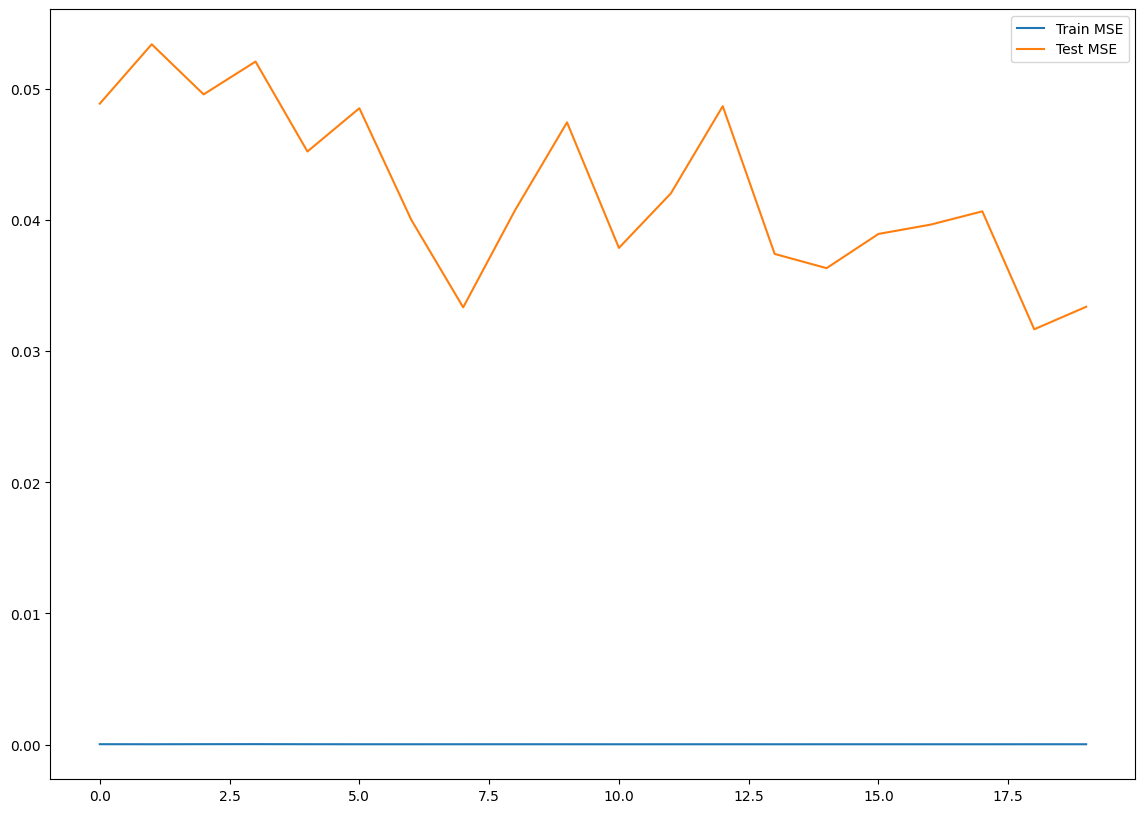

In [29]:
# train_mse와 test_mse의 변화량을 그래프 확인
# 학습 곡선을 확인

plt.figure(figsize=(14, 10))
plt.plot(train_history, label='Train MSE')
plt.plot(test_history, label='Test MSE')

plt.legend()
plt.show()

In [31]:
# 검증 예측, 실제 값을 그래프로 시각화
model.eval()
# 예측 갑스 실제 값을 1차원 리스트에 대입
preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x).cpu()
        preds.append(pred)
        trues.append(y)
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()
# preds, trues 아직 스케일링이 되어있는 상태

# 데이터의 역변환
preds_origin = y_scaler.inverse_transform(preds.reshape(-1, 1)).squeeze()
trues_origin = y_scaler.inverse_transform(trues.reshape(-1, 1)).squeeze()

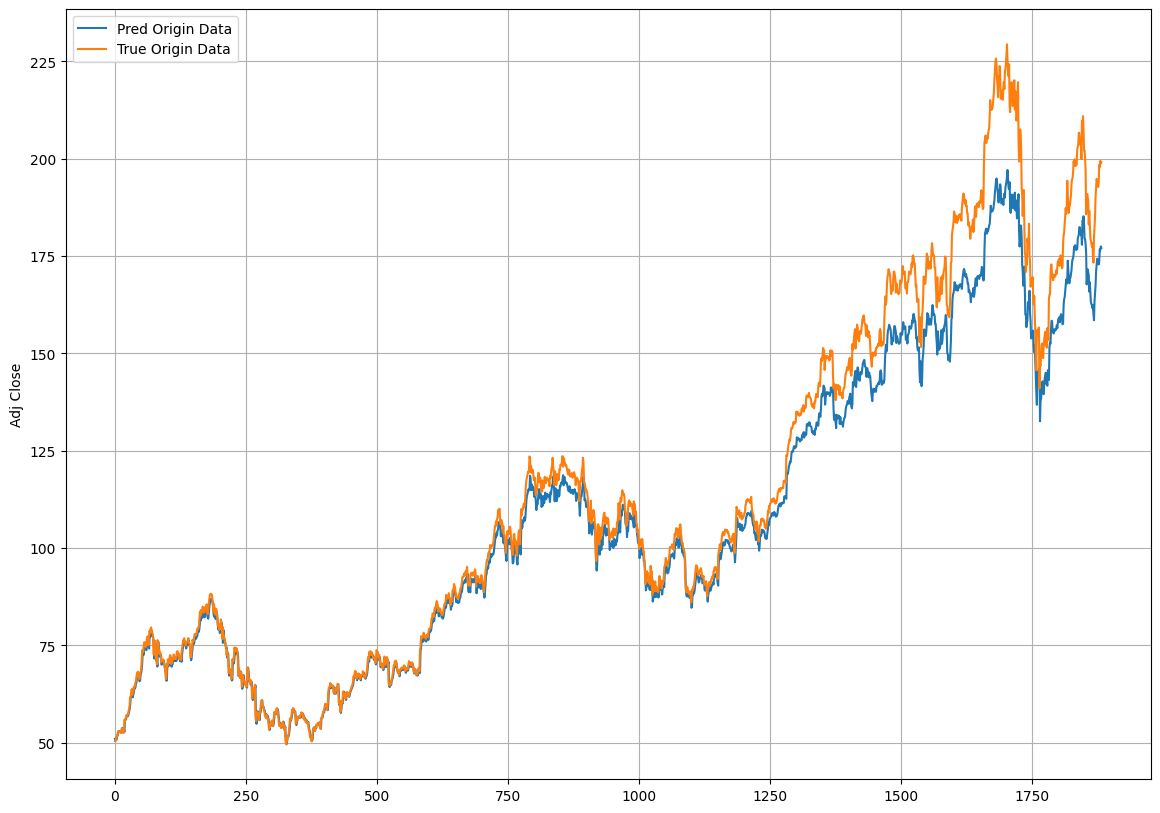

In [33]:
plt.figure(figsize=(14, 10))

plt.plot(preds_origin, label='Pred Origin Data')
plt.plot(trues_origin, label='True Origin Data')

plt.legend()
plt.grid(True)
plt.ylabel('Adj Close')

plt.show()